[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/09_data_aggregation/09_4_Transform.ipynb)

# 09.4: `transform()`: Group-Level Columns

Every groupby operation you have seen so far, including `mean()`, `agg()`, and `sum()`, collapses each group into a smaller result. A group of 33 Asian countries becomes one row. That is usually what you want when building a summary table.

But sometimes the question is different. You do not want to collapse the groups; you want to add information about each group back to every individual row. "How does this country's life expectancy compare to its continent's average?" requires the continent average, but you want it sitting next to each country's own data, not in a separate table you have to join back.

`transform()` does this: it computes a group statistic and broadcasts the result back to every row in the group, preserving the original shape of the DataFrame.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/jennybc/gapminder/main/inst/extdata/gapminder.tsv"
df = pd.read_csv(url, sep="\t")
df2007 = df[df["year"] == 2007].copy().reset_index(drop=True)
df2007.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## `agg()` vs `transform()`: the core distinction

The easiest way to understand `transform()` is to run both on the same groupby and compare the outputs.

In [2]:
agg_result = df2007.groupby("continent")["lifeExp"].mean()
print("agg result shape:", agg_result.shape)
print(agg_result.round(1))

agg result shape: (5,)
continent
Africa      54.8
Americas    73.6
Asia        70.7
Europe      77.6
Oceania     80.7
Name: lifeExp, dtype: float64


Now call `transform()` on the same groupby and compare the shape and values.

In [3]:
transform_result = df2007.groupby("continent")["lifeExp"].transform("mean")
print("transform result shape:", transform_result.shape)
print(transform_result.head(10).round(1))

transform result shape: (142,)
0    70.7
1    77.6
2    54.8
3    54.8
4    73.6
5    80.7
6    77.6
7    70.7
8    70.7
9    77.6
Name: lifeExp, dtype: float64


`agg()` returned 5 rows, one per continent. `transform()` returned 142 rows, one per country, the same as the original DataFrame. But look at the values: every country in Africa has the same value (54.8, the African mean). Every country in Asia has the same value (70.7, the Asian mean). `transform()` computed the group mean and then broadcast it back to every row that belongs to that group.

The practical payoff: you can assign this result directly as a new column.

## Adding a group-level column to the original DataFrame

Because `transform()` returns a Series that matches the original DataFrame's index, you can assign it directly as a new column. No merging or join is needed: the alignment is automatic.

In [4]:
df2007["continent_avg_life"] = df2007.groupby("continent")["lifeExp"].transform("mean")

df2007[["country", "continent", "lifeExp", "continent_avg_life"]].head(10).round(1)

,country,continent,lifeExp,continent_avg_life
0,Afghanistan,Asia,43.8,70.7
1,Albania,Europe,76.4,77.6
2,Algeria,Africa,72.3,54.8
3,Angola,Africa,42.7,54.8
4,Argentina,Americas,75.3,73.6
5,Australia,Oceania,81.2,80.7
6,Austria,Europe,79.8,77.6
7,Bahrain,Asia,75.6,70.7
8,Bangladesh,Asia,64.1,70.7
9,Belgium,Europe,79.4,77.6


Every row now has both its own life expectancy and its continent's average, sitting in the same row. No merge required. The information is aligned automatically because `transform()` preserves the original index.

## Derived columns: comparing each country to its group

With both values in the same row, computing the difference is a single subtraction.

In [5]:
df2007["life_vs_continent"] = df2007["lifeExp"] - df2007["continent_avg_life"]

# Countries farthest above their continental average
df2007.nlargest(8, "life_vs_continent")[["country", "continent", "lifeExp", "continent_avg_life", "life_vs_continent"]].round(1)

,country,continent,lifeExp,continent_avg_life,life_vs_continent
105,Reunion,Africa,76.4,54.8,21.6
75,Libya,Africa,74.0,54.8,19.1
130,Tunisia,Africa,73.9,54.8,19.1
81,Mauritius,Africa,72.8,54.8,18.0
2,Algeria,Africa,72.3,54.8,17.5
38,Egypt,Africa,71.3,54.8,16.5
85,Morocco,Africa,71.2,54.8,16.4
66,Japan,Asia,82.6,70.7,11.9


The table is dominated by Africa: Reunion, Libya, Tunisia, Mauritius, Algeria, Egypt, and Morocco all sit 16 to 22 years above their continental average. That is not because these countries rival Europe (none reaches 77 years); it is because the African mean is pulled so far down by the sub-Saharan AIDS crisis that any country spared the worst of it towers over its own continent's average. Japan, the only non-African country in the top eight, leads Asia at nearly 12 years above the Asian mean. A deviation column always measures distance from the group's own center, so the most extreme values appear wherever the group's center sits far below its healthiest members.

The same column also reveals the countries most below their continental average.

In [6]:
# Countries farthest below their continental average
df2007.nsmallest(8, "life_vs_continent")[["country", "continent", "lifeExp", "continent_avg_life", "life_vs_continent"]].round(1)

,country,continent,lifeExp,continent_avg_life,life_vs_continent
0,Afghanistan,Asia,43.8,70.7,-26.9
121,Swaziland,Africa,39.6,54.8,-15.2
86,Mozambique,Africa,42.1,54.8,-12.7
53,Haiti,Americas,60.9,73.6,-12.7
140,Zambia,Africa,42.4,54.8,-12.4
112,Sierra Leone,Africa,42.6,54.8,-12.2
73,Lesotho,Africa,42.6,54.8,-12.2
3,Angola,Africa,42.7,54.8,-12.1


The single largest negative deviation belongs to Afghanistan, almost 27 years below the Asian average, for the mirror-image reason: Asia's mean is high, so its worst-off member falls a long way beneath it. The rest of the list is sub-Saharan Africa, with Swaziland about 15 years and Mozambique, Zambia, Sierra Leone, Lesotho, and Angola 12 to 13 years below the African average, plus Haiti, about 13 years below the Americas' mean. Reading the two tables together makes the point of the deviation column: each country is measured against its own continent's center, not against the world.

## Visualizing the distribution of deviations

The two tables showed the eight most extreme countries in each direction. To see whether those extremes are lonely outliers or the edge of a broad spread, plot the full distribution of deviations, one panel per continent.

Text(0.5, 1.03, 'Distribution of within-continent life expectancy deviations (2007)')

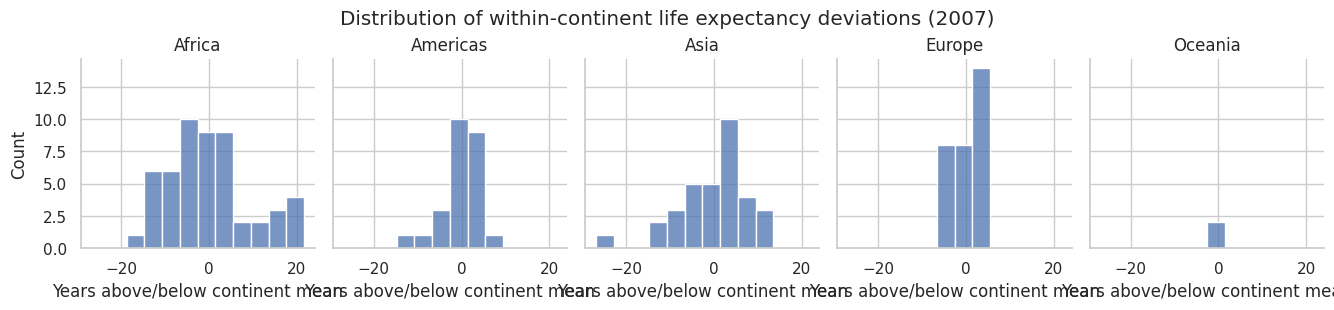

In [7]:
g = sns.displot(
    data=df2007,
    x="life_vs_continent",
    col="continent",
    col_order=["Africa", "Americas", "Asia", "Europe", "Oceania"],
    kind="hist",
    bins=12,
    height=3, aspect=0.9
)
g.set_axis_labels("Years above/below continent mean", "Count")
g.set_titles("{col_name}")
g.figure.suptitle("Distribution of within-continent life expectancy deviations (2007)", y=1.03)

Europe's distribution is tight and roughly symmetric: most countries are within a few years of the European mean. Africa's distribution is wide and left-skewed: most countries are near the mean, but a group of countries is 10 to 20 years below it. Asia shows a more spread distribution in both directions. These patterns were invisible from the raw life expectancy values alone; they only become visible when you compare each country to its own reference group.

## Within-group standardization (z-score)

The deviation column above uses raw years, which makes it easy to interpret but not to compare across continents. A 5-year deviation in Europe (std = 2.9) is a much larger outlier than a 5-year deviation in Africa (std = 9.6). The **z-score** rescales deviations by the group standard deviation so that every group is on the same scale: a z-score of 2.0 means "two standard deviations above the group mean" regardless of which group.

Two `transform()` calls, one for the mean and one for the standard deviation, produce everything needed.

In [8]:
df2007["life_zscore"] = (
    (df2007["lifeExp"] - df2007.groupby("continent")["lifeExp"].transform("mean"))
    / df2007.groupby("continent")["lifeExp"].transform("std")
)

# Top outliers on the z-score scale
df2007.nlargest(5, "life_zscore")[["country", "continent", "lifeExp", "life_zscore"]].round(2)

,country,continent,lifeExp,life_zscore
105,Reunion,Africa,76.44,2.25
75,Libya,Africa,73.95,1.99
130,Tunisia,Africa,73.92,1.98
81,Mauritius,Africa,72.80,1.87
2,Algeria,Africa,72.30,1.82


The top of the z-score table is still African: Reunion's z-score of about 2.3 means it sits more than two standard deviations above the African mean even after accounting for Africa's wide spread (std 9.6). Japan tells the more instructive story. Its raw deviation of nearly 12 years was the largest in Asia, but its z-score is only about 1.5, because Asia's countries are widely spread (std 8.0) and a 12-year gap is less remarkable against that backdrop. Compare Europe: with a std of just 2.9, a country only four and a half years above the European mean earns the same z-score. That is exactly what the z-score is for: it measures how unusual a value is relative to its own group's spread, not how big the raw gap is.

## What's next

You have now used `agg()` to collapse groups into summaries and `transform()` to broadcast group statistics back to every row. Notebook 09.5 introduces `filter()`, which does something different again: it keeps or removes entire groups based on a condition computed across the whole group.